# Pharmaceutical Batch Deviation Detection & CAPA Reporting System

**Author:** Harshitha Gudavalli  
**Degree:** M.S. Biomedical Engineering & Biotechnology  
**Regulatory Framework:** 21 CFR Part 211.192 — cGMP Production Record Review  

---

### Why I built this

During my graduate studies in Biomedical Engineering and Biotechnology, I worked extensively with lab data — running assays, analyzing results, and understanding what happens when test results fall outside acceptable ranges. I noticed that in pharmaceutical manufacturing, catching these failures early and responding with structured corrective actions is one of the most critical QA responsibilities.

This project simulates that exact workflow. I built a Python pipeline that:
- Generates realistic pharmaceutical batch records across multiple drug products
- Automatically detects Out-of-Specification (OOS) results per product-specific acceptance criteria
- Classifies each deviation by severity (Critical, Major, or Minor)
- Recommends structured CAPA actions aligned with FDA 21 CFR Part 211.192
- Visualizes quality trends over time
- Exports a formatted audit-ready Excel report

All data in this notebook is simulated for demonstration purposes.

---

### Notebook Structure

| Section | What it does |
|---|---|
| 1 | Import libraries |
| 2 | Define product specifications and generate batch data |
| 3 | Detect OOS results and classify deviation severity |
| 4 | Visualize quality trends |
| 5 | Auto-generate CAPA recommendations |
| 6 | Export Excel report |
| 7 | Final summary |

## Section 1 — Import Libraries

I'm using pandas for data manipulation, numpy for generating realistic numerical data, matplotlib and seaborn for visualizations, and openpyxl to create the formatted Excel report.

In [9]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, LineChart, Reference
import warnings
warnings.filterwarnings('ignore')

# Set a consistent visual style for all plots
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#F8F9FA'
plt.rcParams['axes.grid']        = True
plt.rcParams['grid.alpha']       = 0.4

print('Libraries loaded successfully.')

Libraries loaded successfully.


## Section 2 — Product Specifications & Batch Data Generation

I selected five common pharmaceutical products and defined their QC acceptance criteria based on standard compendial limits. For each batch I simulate four parameters:

- **Assay (%)** — measures the active ingredient concentration; must stay within the labeled range
- **pH** — affects drug stability and absorption; must stay within product-specific bounds
- **Moisture (%)** — high moisture leads to degradation; must stay below the upper limit
- **Particulates per mL** — a sterility/safety concern; must not exceed USP limits

About 10% of batches are intentionally given deviation-level values to reflect realistic failure rates in manufacturing.

In [10]:
np.random.seed(7)  # For reproducibility

# Each product has its own acceptance criteria based on its dosage form and route
PRODUCT_SPECS = {
    'ALBUTEROL-INH-90MCG':   {'assay': (95.0, 105.0), 'ph': (3.5, 5.5), 'moisture': (0.0, 0.50), 'particulates': (0, 6000)},
    'METFORMIN-TAB-500MG':   {'assay': (98.0, 102.0), 'ph': (6.0, 7.5), 'moisture': (0.0, 1.00), 'particulates': (0, 3000)},
    'AMOXICILLIN-CAP-250MG': {'assay': (90.0, 110.0), 'ph': (4.5, 6.5), 'moisture': (0.0, 2.00), 'particulates': (0, 4000)},
    'ATORVASTATIN-TAB-10MG': {'assay': (98.0, 102.0), 'ph': (5.5, 7.5), 'moisture': (0.0, 0.80), 'particulates': (0, 3500)},
    'LISINOPRIL-TAB-10MG':   {'assay': (95.0, 105.0), 'ph': (5.0, 7.0), 'moisture': (0.0, 1.50), 'particulates': (0, 4500)},
}

ANALYSTS  = ['H. Gudavalli', 'J. Patel', 'M. Rodriguez', 'S. Kim', 'A. Okonkwo']
LINES     = ['Line A', 'Line B', 'Line C', 'Line D']
EQUIPMENT = ['MFG-001', 'MFG-002', 'MFG-003', 'MFG-004']

records   = []
start     = datetime(2024, 1, 3)

for i in range(1, 501):
    product  = np.random.choice(list(PRODUCT_SPECS.keys()))
    sp       = PRODUCT_SPECS[product]
    mfg_date = start + timedelta(days=i // 2)
    is_dev   = np.random.random() < 0.10   # ~10% deviation rate

    # Simulate assay — deviating batches fall outside spec range
    assay_center = 100.0 if not is_dev else np.random.choice([87.0, 109.0])
    assay = round(np.random.normal(assay_center, 1.4), 2)

    # Simulate pH — deviating batches shift below the lower limit
    ph_center = (sp['ph'][0] + sp['ph'][1]) / 2
    ph = round(np.random.normal(ph_center if not is_dev else sp['ph'][0] - 0.5, 0.15), 2)

    # Simulate moisture — deviating batches exceed the upper spec
    mhi     = sp['moisture'][1]
    moisture = round(np.random.uniform(0.05, mhi * 0.82 if not is_dev else mhi * 1.40), 3)

    # Simulate particulates — deviating batches exceed the limit
    phi          = sp['particulates'][1]
    particulates = int(np.random.uniform(400, phi * 0.78 if not is_dev else phi * 1.30))

    # Check which parameters are OOS
    oos_params = []
    if not (sp['assay'][0]       <= assay        <= sp['assay'][1]):       oos_params.append('Assay')
    if not (sp['ph'][0]          <= ph           <= sp['ph'][1]):          oos_params.append('pH')
    if not (sp['moisture'][0]    <= moisture     <= sp['moisture'][1]):    oos_params.append('Moisture')
    if not (sp['particulates'][0]<= particulates <= sp['particulates'][1]):oos_params.append('Particulates')

    n_oos = len(oos_params)

    # Severity classification: more parameters failing = higher risk
    if n_oos == 0:
        severity = 'None'
        status   = 'Released'
    elif n_oos == 1:
        severity = 'Minor'
        status   = 'Under Investigation'
    elif n_oos == 2:
        severity = 'Major'
        status   = 'Rejected'
    else:
        severity = 'Critical'
        status   = 'Rejected'

    prefix = product.split('-')[0][:3]
    year   = 2024 if i <= 300 else 2025

    records.append({
        'Batch_ID':             f'BT-{prefix}-{year}-{str(i).zfill(4)}',
        'Product_Name':         product,
        'Manufacturing_Date':   mfg_date.strftime('%Y-%m-%d'),
        'Month':                mfg_date.strftime('%Y-%m'),
        'Batch_Size_kg':        np.random.choice([50, 100, 150, 200, 250]),
        'Manufacturing_Line':   np.random.choice(LINES),
        'Equipment_ID':         np.random.choice(EQUIPMENT),
        'Analyst':              np.random.choice(ANALYSTS),
        'Assay_Pct':            assay,
        'Spec_Assay':           f"{sp['assay'][0]}–{sp['assay'][1]}%",
        'pH':                   ph,
        'Spec_pH':              f"{sp['ph'][0]}–{sp['ph'][1]}",
        'Moisture_Pct':         moisture,
        'Spec_Moisture':        f"≤{sp['moisture'][1]}%",
        'Particulates_per_mL':  particulates,
        'Spec_Particulates':    f"≤{sp['particulates'][1]}",
        'OOS_Flag':             'YES' if oos_params else 'NO',
        'OOS_Parameters':       ', '.join(oos_params) if oos_params else 'None',
        'Deviation_Severity':   severity,
        'Batch_Status':         status,
        'CFR_Reference':        '21 CFR Part 211.192',
    })

df    = pd.DataFrame(records)
oos   = df[df['OOS_Flag'] == 'YES'].copy()
prate = round((len(df) - len(oos)) / len(df) * 100, 1)

print(f'Batch records generated : {len(df)}')
print(f'OOS batches detected    : {len(oos)}')
print(f'Overall pass rate       : {prate}%')
print()
print('Severity breakdown:')
print(df['Deviation_Severity'].value_counts().to_string())

df.head(8)

Batch records generated : 500
OOS batches detected    : 64
Overall pass rate       : 87.2%

Severity breakdown:
Deviation_Severity
None        436
Minor        23
Major        22
Critical     19


,Batch_ID,Product_Name,Manufacturing_Date,Month,Batch_Size_kg,Manufacturing_Line,Equipment_ID,Analyst,Assay_Pct,Spec_Assay,...,Spec_pH,Moisture_Pct,Spec_Moisture,Particulates_per_mL,Spec_Particulates,OOS_Flag,OOS_Parameters,Deviation_Severity,Batch_Status,CFR_Reference
0,BT-LIS-2024-0001,LISINOPRIL-TAB-10MG,2024-01-03,2024-01,50,Line B,MFG-003,M. Rodriguez,102.37,95.0–105.0%,...,5.0–7.0,1.204,≤1.5%,2074,≤4500,NO,None,None,Released,21 CFR Part 211.192
1,BT-AMO-2024-0002,AMOXICILLIN-CAP-250MG,2024-01-04,2024-01,150,Line C,MFG-004,A. Okonkwo,88.42,90.0–110.0%,...,4.5–6.5,1.098,≤2.0%,716,≤4000,YES,"Assay, pH",Major,Rejected,21 CFR Part 211.192
2,BT-LIS-2024-0003,LISINOPRIL-TAB-10MG,2024-01-04,2024-01,150,Line A,MFG-002,A. Okonkwo,99.82,95.0–105.0%,...,5.0–7.0,0.936,≤1.5%,1192,≤4500,NO,None,None,Released,21 CFR Part 211.192
3,BT-MET-2024-0004,METFORMIN-TAB-500MG,2024-01-05,2024-01,250,Line A,MFG-001,M. Rodriguez,97.82,98.0–102.0%,...,6.0–7.5,0.199,≤1.0%,594,≤3000,YES,Assay,Minor,Under Investigation,21 CFR Part 211.192
4,BT-MET-2024-0005,METFORMIN-TAB-500MG,2024-01-05,2024-01,200,Line B,MFG-004,S. Kim,98.96,98.0–102.0%,...,6.0–7.5,0.491,≤1.0%,935,≤3000,NO,None,None,Released,21 CFR Part 211.192
5,BT-ATO-2024-0006,ATORVASTATIN-TAB-10MG,2024-01-06,2024-01,100,Line B,MFG-002,M. Rodriguez,99.83,98.0–102.0%,...,5.5–7.5,0.304,≤0.8%,2697,≤3500,NO,None,None,Released,21 CFR Part 211.192
6,BT-ATO-2024-0007,ATORVASTATIN-TAB-10MG,2024-01-06,2024-01,200,Line B,MFG-002,A. Okonkwo,100.54,98.0–102.0%,...,5.5–7.5,0.301,≤0.8%,403,≤3500,NO,None,None,Released,21 CFR Part 211.192
7,BT-ATO-2024-0008,ATORVASTATIN-TAB-10MG,2024-01-07,2024-01,250,Line D,MFG-001,M. Rodriguez,100.14,98.0–102.0%,...,5.5–7.5,0.082,≤0.8%,1119,≤3500,NO,None,None,Released,21 CFR Part 211.192


## Section 3 — OOS Detection Summary

Here I filter all batches that failed one or more QC parameters and break them down by product, parameter, and severity. This mirrors the first step a QA analyst performs during a batch record review.

In [11]:
print('--- OOS Batch Summary ---\n')
print(f'Total OOS batches : {len(oos)}\n')

print('OOS count by QC parameter:')
for param in ['Assay', 'pH', 'Moisture', 'Particulates']:
    count = oos['OOS_Parameters'].str.contains(param).sum()
    bar   = '|' * count
    print(f'  {param:<14} {bar} ({count})')

print()
print('OOS count by product:')
print(oos['Product_Name'].value_counts().to_string())

print()
print('Severity breakdown (OOS batches only):')
for s in ['Critical', 'Major', 'Minor']:
    n = len(oos[oos['Deviation_Severity'] == s])
    print(f'  {s:<10} : {n}')

print()
print('Sample OOS records:')
oos[['Batch_ID','Product_Name','OOS_Parameters','Deviation_Severity','Batch_Status']].head(10)

--- OOS Batch Summary ---

Total OOS batches : 64

OOS count by QC parameter:
  Assay          |||||||||||||||||||||||||||||||||||||||||||||||||||||||||||| (60)
  pH             |||||||||||||||||||||||||||||||||||||||||| (42)
  Moisture       |||||||||||||| (14)
  Particulates   |||||||||||| (12)

OOS count by product:
Product_Name
ATORVASTATIN-TAB-10MG    21
ALBUTEROL-INH-90MCG      14
METFORMIN-TAB-500MG      13
AMOXICILLIN-CAP-250MG     9
LISINOPRIL-TAB-10MG       7

Severity breakdown (OOS batches only):
  Critical   : 19
  Major      : 22
  Minor      : 23

Sample OOS records:


,Batch_ID,Product_Name,OOS_Parameters,Deviation_Severity,Batch_Status
1,BT-AMO-2024-0002,AMOXICILLIN-CAP-250MG,"Assay, pH",Major,Rejected
3,BT-MET-2024-0004,METFORMIN-TAB-500MG,Assay,Minor,Under Investigation
13,BT-AMO-2024-0014,AMOXICILLIN-CAP-250MG,pH,Minor,Under Investigation
17,BT-ALB-2024-0018,ALBUTEROL-INH-90MCG,"Assay, pH",Major,Rejected
28,BT-MET-2024-0029,METFORMIN-TAB-500MG,"Assay, pH",Major,Rejected
30,BT-ATO-2024-0031,ATORVASTATIN-TAB-10MG,Assay,Minor,Under Investigation
34,BT-MET-2024-0035,METFORMIN-TAB-500MG,"Assay, pH, Moisture",Critical,Rejected
35,BT-ATO-2024-0036,ATORVASTATIN-TAB-10MG,Assay,Minor,Under Investigation
45,BT-ALB-2024-0046,ALBUTEROL-INH-90MCG,"Assay, pH, Particulates",Critical,Rejected
60,BT-MET-2024-0061,METFORMIN-TAB-500MG,Assay,Minor,Under Investigation


## Section 4 — Quality Trend Visualizations

I created four charts that reflect the kind of trend analysis a QA team would review in a monthly quality meeting:

1. Monthly deviation count broken down by severity
2. Monthly OOS rate trend with average reference line
3. Overall severity distribution (donut chart)
4. OOS rate by product with an alert threshold

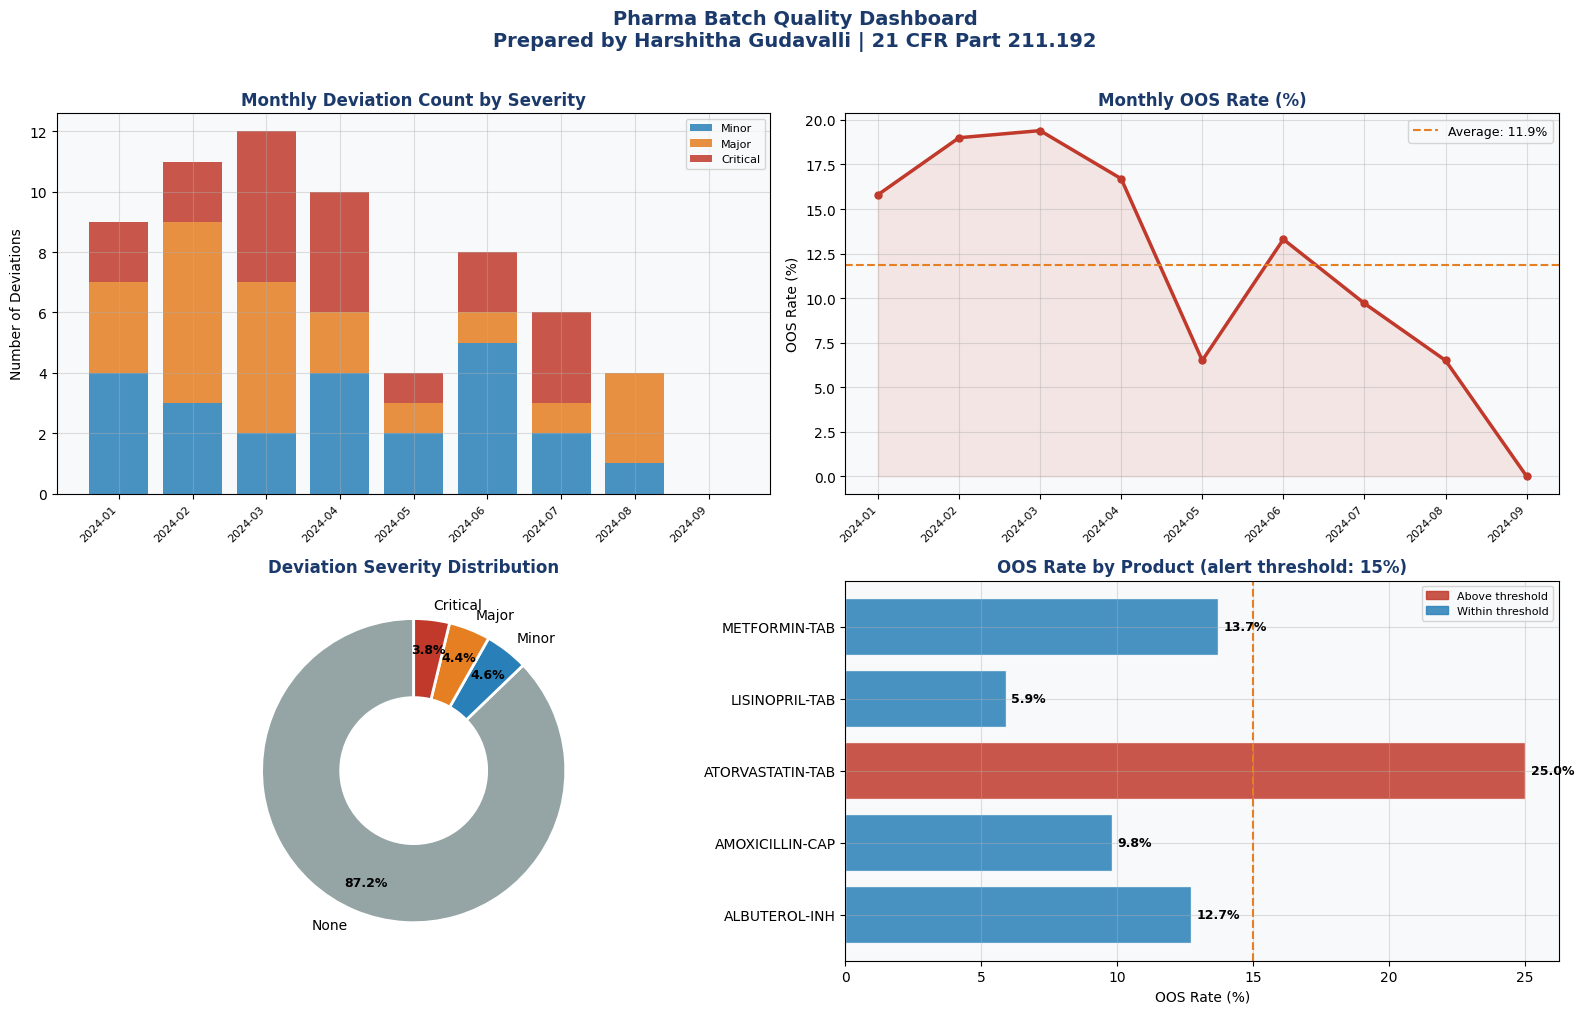

Dashboard saved as QA_Dashboard_HGudavalli.png


In [12]:
# Aggregate data by month
monthly = df.groupby('Month').agg(
    Total    = ('Batch_ID', 'count'),
    OOS      = ('OOS_Flag', lambda x: (x == 'YES').sum()),
    Critical = ('Deviation_Severity', lambda x: (x == 'Critical').sum()),
    Major    = ('Deviation_Severity', lambda x: (x == 'Major').sum()),
    Minor    = ('Deviation_Severity', lambda x: (x == 'Minor').sum()),
).reset_index()
monthly['OOS_Rate_Pct'] = (monthly['OOS'] / monthly['Total'] * 100).round(1)

# Aggregate data by product
by_product = df.groupby('Product_Name').agg(
    Total = ('Batch_ID', 'count'),
    OOS   = ('OOS_Flag', lambda x: (x == 'YES').sum()),
).reset_index()
by_product['OOS_Rate_Pct']  = (by_product['OOS'] / by_product['Total'] * 100).round(1)
by_product['Product_Short'] = by_product['Product_Name'].str.split('-').str[:2].str.join('-')

PALETTE = {'Critical': '#C0392B', 'Major': '#E67E22', 'Minor': '#2980B9', 'Released': '#27AE60'}
x_idx   = list(range(len(monthly)))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    'Pharma Batch Quality Dashboard\nPrepared by Harshitha Gudavalli | 21 CFR Part 211.192',
    fontsize=14, fontweight='bold', color='#1B3A6B', y=1.01
)

# Chart 1 — Stacked bar: monthly deviation count by severity
ax = axes[0, 0]
ax.bar(x_idx, monthly['Minor'],    label='Minor',    color=PALETTE['Minor'],    alpha=0.85)
ax.bar(x_idx, monthly['Major'],    label='Major',    color=PALETTE['Major'],    alpha=0.85, bottom=monthly['Minor'])
ax.bar(x_idx, monthly['Critical'], label='Critical', color=PALETTE['Critical'], alpha=0.85, bottom=monthly['Minor']+monthly['Major'])
ax.set_xticks(x_idx)
ax.set_xticklabels(monthly['Month'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Deviation Count by Severity', fontweight='bold', color='#1B3A6B')
ax.set_ylabel('Number of Deviations')
ax.legend(fontsize=8)

# Chart 2 — Line: monthly OOS rate
ax = axes[0, 1]
avg_rate = monthly['OOS_Rate_Pct'].mean()
ax.plot(x_idx, monthly['OOS_Rate_Pct'], color='#C0392B', linewidth=2.5, marker='o', markersize=5)
ax.axhline(y=avg_rate, color='#E67E22', linestyle='--', linewidth=1.5, label=f'Average: {avg_rate:.1f}%')
ax.fill_between(x_idx, monthly['OOS_Rate_Pct'], alpha=0.1, color='#C0392B')
ax.set_xticks(x_idx)
ax.set_xticklabels(monthly['Month'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly OOS Rate (%)', fontweight='bold', color='#1B3A6B')
ax.set_ylabel('OOS Rate (%)')
ax.legend(fontsize=9)

# Chart 3 — Donut: severity distribution
ax = axes[1, 0]
sev_counts = df['Deviation_Severity'].value_counts()
colors     = [PALETTE.get(s, '#95A5A6') for s in sev_counts.index]
wedges, texts, autotexts = ax.pie(
    sev_counts.values, labels=sev_counts.index, colors=colors,
    autopct='%1.1f%%', startangle=90, pctdistance=0.80,
    wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
ax.set_title('Deviation Severity Distribution', fontweight='bold', color='#1B3A6B')

# Chart 4 — Horizontal bar: OOS rate by product
ax = axes[1, 1]
bar_colors = ['#C0392B' if r > 15 else '#2980B9' for r in by_product['OOS_Rate_Pct']]
bars = ax.barh(by_product['Product_Short'], by_product['OOS_Rate_Pct'], color=bar_colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, by_product['OOS_Rate_Pct']):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(x=15, color='#E67E22', linestyle='--', linewidth=1.5)
ax.set_title('OOS Rate by Product (alert threshold: 15%)', fontweight='bold', color='#1B3A6B')
ax.set_xlabel('OOS Rate (%)')
above = mpatches.Patch(color='#C0392B', alpha=0.85, label='Above threshold')
below = mpatches.Patch(color='#2980B9', alpha=0.85, label='Within threshold')
ax.legend(handles=[above, below], fontsize=8)

plt.tight_layout()
plt.savefig('QA_Dashboard_HGudavalli.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved as QA_Dashboard_HGudavalli.png')

## Section 5 — Parameter Deep Dive

This section looks more closely at assay distribution and which QC parameters fail most often. Understanding which parameter drives the most OOS results helps prioritize where corrective action is needed first.

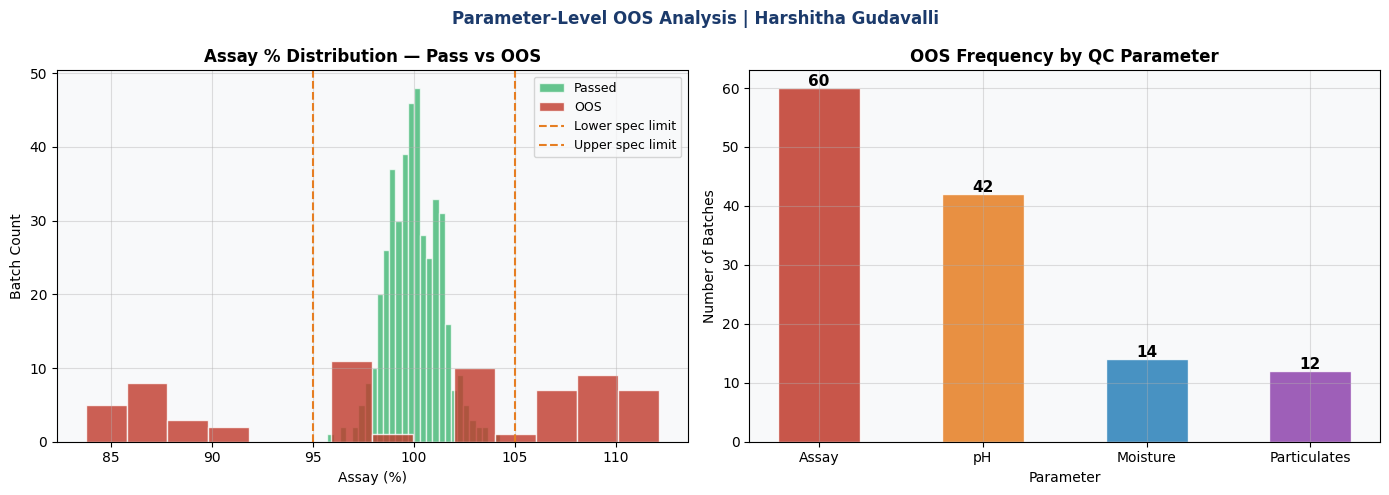

Chart saved as OOS_Parameter_HGudavalli.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Parameter-Level OOS Analysis | Harshitha Gudavalli', fontsize=12, fontweight='bold', color='#1B3A6B')

# Assay distribution — compare passing vs failing batches
ax = axes[0]
passed_assay = df[df['OOS_Flag'] == 'NO']['Assay_Pct']
failed_assay = df[df['OOS_Flag'] == 'YES']['Assay_Pct']
ax.hist(passed_assay, bins=28, alpha=0.7, color='#27AE60', label='Passed', edgecolor='white')
ax.hist(failed_assay, bins=14, alpha=0.8, color='#C0392B', label='OOS',    edgecolor='white')
ax.axvline(x=95,  color='#E67E22', linestyle='--', linewidth=1.5, label='Lower spec limit')
ax.axvline(x=105, color='#E67E22', linestyle='--', linewidth=1.5, label='Upper spec limit')
ax.set_title('Assay % Distribution — Pass vs OOS', fontweight='bold')
ax.set_xlabel('Assay (%)')
ax.set_ylabel('Batch Count')
ax.legend(fontsize=9)

# OOS parameter frequency
ax = axes[1]
param_freq = {p: oos['OOS_Parameters'].str.contains(p).sum() for p in ['Assay', 'pH', 'Moisture', 'Particulates']}
p_colors   = ['#C0392B', '#E67E22', '#2980B9', '#8E44AD']
bars = ax.bar(param_freq.keys(), param_freq.values(), color=p_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, val in zip(bars, param_freq.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, str(val), ha='center', fontweight='bold', fontsize=11)
ax.set_title('OOS Frequency by QC Parameter', fontweight='bold')
ax.set_ylabel('Number of Batches')
ax.set_xlabel('Parameter')

plt.tight_layout()
plt.savefig('OOS_Parameter_HGudavalli.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as OOS_Parameter_HGudavalli.png')

## Section 6 — CAPA Recommendation Engine

For each OOS batch, the system generates a structured CAPA record. Each record includes a likely root cause, a corrective action to fix the current problem, and a preventive action to stop it from recurring. This is the core of what a QA analyst does after an OOS is confirmed.

CAPA records are referenced to 21 CFR Part 211.192 which requires that all production and control records be reviewed prior to release.

In [14]:
# CAPA knowledge base — one entry per OOS parameter type
CAPA_LIBRARY = {
    'Assay': {
        'Root_Cause':          'Possible weighing or dilution error during active ingredient compounding',
        'Corrective_Action':   'Quarantine batch; retest from retained reserve sample per SOP-QC-012',
        'Preventive_Action':   'Implement dual-analyst verification for all compounding gravimetric steps',
        'Target_Closure_Days': 30
    },
    'pH': {
        'Root_Cause':          'Buffer preparation error or pH meter calibration drift',
        'Corrective_Action':   'Recalibrate pH meter with fresh standards; retest batch pH',
        'Preventive_Action':   'Schedule quarterly operational qualification (OQ) for all pH meters',
        'Target_Closure_Days': 21
    },
    'Moisture': {
        'Root_Cause':          'Humidity excursion in drying or packaging suite during manufacturing',
        'Corrective_Action':   'Review HVAC logs and drying oven records for the batch date',
        'Preventive_Action':   'Install continuous humidity monitoring with automated alarms in drying suite',
        'Target_Closure_Days': 30
    },
    'Particulates': {
        'Root_Cause':          'Filter integrity failure or contamination from manufacturing equipment',
        'Corrective_Action':   'Perform filter integrity test; execute clean-in-place on filling line',
        'Preventive_Action':   'Increase filter integrity testing frequency to once per batch',
        'Target_Closure_Days': 14
    },
}

capa_records = []
capa_num     = 1

for _, row in oos.iterrows():
    params = [p.strip() for p in row['OOS_Parameters'].split(',') if p.strip() != 'None']
    if not params:
        continue
    primary   = params[0]  # Prioritize the first failing parameter
    capa_info = CAPA_LIBRARY.get(primary)
    if not capa_info:
        continue

    capa_records.append({
        'CAPA_ID':             f'CAPA-HG-{str(capa_num).zfill(4)}',
        'Batch_ID':            row['Batch_ID'],
        'Product':             row['Product_Name'],
        'OOS_Parameter':       primary,
        'Severity':            row['Deviation_Severity'],
        'Root_Cause':          capa_info['Root_Cause'],
        'Corrective_Action':   capa_info['Corrective_Action'],
        'Preventive_Action':   capa_info['Preventive_Action'],
        'Target_Closure_Days': capa_info['Target_Closure_Days'],
        'Status':              'Open',
        'CFR_Reference':       '21 CFR Part 211.192',
    })
    capa_num += 1

capa_df = pd.DataFrame(capa_records)

print(f'CAPA records generated: {len(capa_df)}')
print()
print('Breakdown by severity:')
print(capa_df['Severity'].value_counts().to_string())
print()
print('Breakdown by primary OOS parameter:')
print(capa_df['OOS_Parameter'].value_counts().to_string())
print()
capa_df[['CAPA_ID','Batch_ID','OOS_Parameter','Severity','Root_Cause','Status']].head(8)

CAPA records generated: 64

Breakdown by severity:
Severity
Minor       23
Major       22
Critical    19

Breakdown by primary OOS parameter:
OOS_Parameter
Assay    60
pH        4



,CAPA_ID,Batch_ID,OOS_Parameter,Severity,Root_Cause,Status
0,CAPA-HG-0001,BT-AMO-2024-0002,Assay,Major,Possible weighing or dilution error during act...,Open
1,CAPA-HG-0002,BT-MET-2024-0004,Assay,Minor,Possible weighing or dilution error during act...,Open
2,CAPA-HG-0003,BT-AMO-2024-0014,pH,Minor,Buffer preparation error or pH meter calibrati...,Open
3,CAPA-HG-0004,BT-ALB-2024-0018,Assay,Major,Possible weighing or dilution error during act...,Open
4,CAPA-HG-0005,BT-MET-2024-0029,Assay,Major,Possible weighing or dilution error during act...,Open
5,CAPA-HG-0006,BT-ATO-2024-0031,Assay,Minor,Possible weighing or dilution error during act...,Open
6,CAPA-HG-0007,BT-MET-2024-0035,Assay,Critical,Possible weighing or dilution error during act...,Open
7,CAPA-HG-0008,BT-ATO-2024-0036,Assay,Minor,Possible weighing or dilution error during act...,Open


## Section 7 — Export Professional Excel Report

The final output is a formatted, multi-sheet Excel workbook that looks like a real QA document. I use openpyxl to apply color coding, borders, freeze panes, and auto-filters — the same formatting conventions used in pharma QA document control systems.

In [15]:
OUTPUT_FILE  = 'BatchQA_CAPA_Report_HGudavalli.xlsx'
REPORT_DATE  = datetime.today().strftime('%Y-%m-%d')

# Reusable style helpers
def thin_border():
    s = Side(style='thin', color='BFBFBF')
    return Border(left=s, right=s, top=s, bottom=s)

def write_header(ws, row, col, text, bg='1B3A6B', fg='FFFFFF', size=10):
    c = ws.cell(row, col, text)
    c.font      = Font(name='Arial', size=size, bold=True, color=fg)
    c.fill      = PatternFill('solid', fgColor=bg)
    c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    c.border    = thin_border()
    return c

def write_cell(ws, row, col, text, bg='FFFFFF', bold=False, size=9, align='center', wrap=True):
    c = ws.cell(row, col, text)
    c.font      = Font(name='Arial', size=size, bold=bold)
    c.fill      = PatternFill('solid', fgColor=bg)
    c.alignment = Alignment(horizontal=align, vertical='center', wrap_text=wrap)
    c.border    = thin_border()
    return c

SEV_BG = {'Critical':'F8D7DA', 'Major':'FFF3CD', 'Minor':'D6E4F7', 'None':'D4EDDA'}
SEV_FG = {'Critical':'721C24', 'Major':'856404', 'Minor':'1B3A6B', 'None':'155724'}

wb = Workbook()

# ── Sheet 1: Full Batch Log ────────────────────────────────────────────────
ws1 = wb.active
ws1.title = 'Batch Log'

ws1.merge_cells('A1:N1')
c = ws1.cell(1, 1, 'BATCH RECORD LOG — 21 CFR Part 211.192 | Harshitha Gudavalli | ' + REPORT_DATE)
c.font      = Font(name='Arial', size=12, bold=True, color='FFFFFF')
c.fill      = PatternFill('solid', fgColor='1B3A6B')
c.alignment = Alignment(horizontal='center', vertical='center')
ws1.row_dimensions[1].height = 26

headers  = ['Batch ID','Product','Mfg Date','Size (kg)','Line','Equipment',
             'Analyst','Assay %','Spec Assay','pH','Spec pH','OOS Flag','OOS Parameters','Severity']
keys     = ['Batch_ID','Product_Name','Manufacturing_Date','Batch_Size_kg',
             'Manufacturing_Line','Equipment_ID','Analyst','Assay_Pct','Spec_Assay',
             'pH','Spec_pH','OOS_Flag','OOS_Parameters','Deviation_Severity']
widths   = [18, 26, 12, 11, 9, 12, 14, 10, 15, 8, 13, 10, 22, 12]

for ci, (h, w) in enumerate(zip(headers, widths), 1):
    write_header(ws1, 2, ci, h)
    ws1.column_dimensions[get_column_letter(ci)].width = w

for ri, (_, row) in enumerate(df.iterrows()):
    er  = 3 + ri
    alt = 'FAFAFA' if ri % 2 == 0 else 'FFFFFF'
    sev = row['Deviation_Severity']
    for ci, key in enumerate(keys, 1):
        val = row[key]
        if key == 'Deviation_Severity':
            c = ws1.cell(er, ci, val)
            c.font      = Font(name='Arial', size=9, bold=True, color=SEV_FG.get(sev,'000000'))
            c.fill      = PatternFill('solid', fgColor=SEV_BG.get(sev,'FFFFFF'))
            c.alignment = Alignment(horizontal='center', vertical='center')
            c.border    = thin_border()
        elif key == 'OOS_Flag' and val == 'YES':
            c = write_cell(ws1, er, ci, val, bg='F8D7DA', bold=True)
            c.font = Font(name='Arial', size=9, bold=True, color='721C24')
        else:
            write_cell(ws1, er, ci, val, bg=alt)

ws1.freeze_panes = 'A3'
ws1.auto_filter.ref = f'A2:{get_column_letter(len(headers))}2'

# ── Sheet 2: OOS Investigation ─────────────────────────────────────────────
ws2 = wb.create_sheet('OOS Investigation')

ws2.merge_cells('A1:J1')
c = ws2.cell(1, 1, f'OOS INVESTIGATION LOG — {len(oos)} Deviations Identified | 21 CFR Part 211.192')
c.font      = Font(name='Arial', size=12, bold=True, color='FFFFFF')
c.fill      = PatternFill('solid', fgColor='1B3A6B')
c.alignment = Alignment(horizontal='center', vertical='center')
ws2.row_dimensions[1].height = 26

oos_headers = ['Batch ID','Product','Mfg Date','Analyst','OOS Parameters','Severity','Assay %','Spec Assay','pH','Batch Status']
oos_keys    = ['Batch_ID','Product_Name','Manufacturing_Date','Analyst','OOS_Parameters','Deviation_Severity','Assay_Pct','Spec_Assay','pH','Batch_Status']
oos_widths  = [18, 26, 12, 14, 22, 12, 10, 15, 8, 20]

for ci, (h, w) in enumerate(zip(oos_headers, oos_widths), 1):
    write_header(ws2, 2, ci, h)
    ws2.column_dimensions[get_column_letter(ci)].width = w

for ri, (_, row) in enumerate(oos.iterrows()):
    er  = 3 + ri
    alt = 'FAFAFA' if ri % 2 == 0 else 'FFFFFF'
    sev = row['Deviation_Severity']
    for ci, key in enumerate(oos_keys, 1):
        val = row[key]
        if key == 'Deviation_Severity':
            c = ws2.cell(er, ci, val)
            c.font      = Font(name='Arial', size=9, bold=True, color=SEV_FG.get(sev,'000000'))
            c.fill      = PatternFill('solid', fgColor=SEV_BG.get(sev,'FFFFFF'))
            c.alignment = Alignment(horizontal='center', vertical='center')
            c.border    = thin_border()
        else:
            write_cell(ws2, er, ci, val, bg=alt)

ws2.freeze_panes = 'A3'

# ── Sheet 3: CAPA Log ──────────────────────────────────────────────────────
ws3 = wb.create_sheet('CAPA Log')

ws3.merge_cells('A1:K1')
c = ws3.cell(1, 1, 'CORRECTIVE & PREVENTIVE ACTION (CAPA) LOG | Prepared by: Harshitha Gudavalli')
c.font      = Font(name='Arial', size=12, bold=True, color='FFFFFF')
c.fill      = PatternFill('solid', fgColor='1B3A6B')
c.alignment = Alignment(horizontal='center', vertical='center')
ws3.row_dimensions[1].height = 26

capa_headers = ['CAPA ID','Batch ID','Product','OOS Parameter','Severity','Root Cause','Corrective Action','Preventive Action','Closure (Days)','Status','CFR Reference']
capa_keys    = ['CAPA_ID','Batch_ID','Product','OOS_Parameter','Severity','Root_Cause','Corrective_Action','Preventive_Action','Target_Closure_Days','Status','CFR_Reference']
capa_widths  = [16, 18, 24, 16, 12, 38, 38, 38, 16, 12, 20]

for ci, (h, w) in enumerate(zip(capa_headers, capa_widths), 1):
    write_header(ws3, 2, ci, h)
    ws3.column_dimensions[get_column_letter(ci)].width = w

for ri, (_, row) in enumerate(capa_df.iterrows()):
    er  = 3 + ri
    alt = 'FAFAFA' if ri % 2 == 0 else 'FFFFFF'
    sev = row['Severity']
    ws3.row_dimensions[er].height = 48
    for ci, key in enumerate(capa_keys, 1):
        val = row[key]
        if key == 'Severity':
            c = ws3.cell(er, ci, val)
            c.font      = Font(name='Arial', size=9, bold=True, color=SEV_FG.get(sev,'000000'))
            c.fill      = PatternFill('solid', fgColor=SEV_BG.get(sev,'FFFFFF'))
            c.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
            c.border    = thin_border()
        elif key == 'Status':
            c = ws3.cell(er, ci, val)
            c.font      = Font(name='Arial', size=9, bold=True, color='856404')
            c.fill      = PatternFill('solid', fgColor='FFF3CD')
            c.alignment = Alignment(horizontal='center', vertical='center')
            c.border    = thin_border()
        else:
            write_cell(ws3, er, ci, val, bg=alt, align='left')

ws3.freeze_panes = 'A3'

# ── Sheet 4: Monthly Trend Summary ─────────────────────────────────────────
ws4 = wb.create_sheet('Trend Summary')

ws4.merge_cells('A1:G1')
c = ws4.cell(1, 1, 'MONTHLY BATCH QUALITY TREND | 21 CFR Part 211.192')
c.font      = Font(name='Arial', size=12, bold=True, color='FFFFFF')
c.fill      = PatternFill('solid', fgColor='1B3A6B')
c.alignment = Alignment(horizontal='center', vertical='center')
ws4.row_dimensions[1].height = 26

trend_headers = ['Month','Total Batches','OOS Count','OOS Rate %','Critical','Major','Minor']
trend_keys    = ['Month','Total','OOS','OOS_Rate_Pct','Critical','Major','Minor']
trend_widths  = [16, 16, 14, 14, 12, 12, 12]

for ci, (h, w) in enumerate(zip(trend_headers, trend_widths), 1):
    write_header(ws4, 2, ci, h)
    ws4.column_dimensions[get_column_letter(ci)].width = w

for ri, (_, row) in enumerate(monthly.iterrows()):
    er  = 3 + ri
    alt = 'FAFAFA' if ri % 2 == 0 else 'FFFFFF'
    for ci, key in enumerate(trend_keys, 1):
        write_cell(ws4, er, ci, row[key], bg=alt)

# Embed a bar chart in the trend sheet
chart = BarChart()
chart.type    = 'col'
chart.title   = 'Monthly OOS Batch Count'
chart.style   = 10
chart.width   = 22
chart.height  = 12
data_ref = Reference(ws4, min_col=3, max_col=3, min_row=2, max_row=2+len(monthly))
cats_ref = Reference(ws4, min_col=1, min_row=3, max_row=2+len(monthly))
chart.add_data(data_ref, titles_from_data=True)
chart.set_categories(cats_ref)
ws4.add_chart(chart, f'A{5+len(monthly)}')

wb.save(OUTPUT_FILE)
print(f'Excel report saved: {OUTPUT_FILE}')
print(f'Sheets: {[s.title for s in wb.worksheets]}')

# Auto-download in Colab
try:
    from google.colab import files
    files.download(OUTPUT_FILE)
    print('Download started.')
except:
    print('Open the file from the Colab file browser on the left sidebar.')

Excel report saved: BatchQA_CAPA_Report_HGudavalli.xlsx
Sheets: ['Batch Log', 'OOS Investigation', 'CAPA Log', 'Trend Summary']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.


## Section 8 — Final Summary

In [16]:
print('=' * 58)
print('  PROJECT SUMMARY — Harshitha Gudavalli')
print('  M.S. Biomedical Engineering & Biotechnology')
print('=' * 58)
print(f'  Regulatory standard  : 21 CFR Part 211.192 (cGMP)')
print(f'  Total batches        : {len(df)}')
print(f'  OOS batches          : {len(oos)}')
print(f'  Overall pass rate    : {prate}%')
print(f'  CAPA records created : {len(capa_df)}')
print()
print('  Severity breakdown:')
for s in ['Critical', 'Major', 'Minor', 'None']:
    n = len(df[df['Deviation_Severity'] == s])
    print(f'    {s:<10} : {n}')
print()
print('  Output files:')
print(f'    BatchQA_CAPA_Report_HGudavalli.xlsx')
print(f'    QA_Dashboard_HGudavalli.png')
print(f'    OOS_Parameter_HGudavalli.png')
print('=' * 58)

  PROJECT SUMMARY — Harshitha Gudavalli
  M.S. Biomedical Engineering & Biotechnology
  Regulatory standard  : 21 CFR Part 211.192 (cGMP)
  Total batches        : 500
  OOS batches          : 64
  Overall pass rate    : 87.2%
  CAPA records created : 64

  Severity breakdown:
    Critical   : 19
    Major      : 22
    Minor      : 23
    None       : 436

  Output files:
    BatchQA_CAPA_Report_HGudavalli.xlsx
    QA_Dashboard_HGudavalli.png
    OOS_Parameter_HGudavalli.png
